In [1]:
import numpy as np
import pandas as pd
import os
import subprocess
Dir_working = r'Z:\study\phd\project\Semantics\Dissemination\table_figure'

pipeline = 'conjunction_unsmoothed'

folder = 'p005FDR'
Dir_output = os.path.join(Dir_working,'workbench',pipeline,folder)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)

# path_wb = r'D:\Software\fmri\workbench\bin_windows64'
# path_wb_atlas = r'D:\Software\fmri\workbench\atlas'
path_wb = r'Z:\Software\workbench\bin_windows64'
path_wb_atlas = r'Z:\Software\workbench\atlas'

In [2]:
def import_data(path_master,path_txtTemplate):
    # path_master = options['path_master']
    # path_txtTemplate = options['path_txtTemplate']

    ### read result table ###
    df = pd.read_excel(path_master)
    df['Region'] = df['Region'].astype(str)
    df = df.loc[df['ROI_idx']<=360]
    df['LR'] = 'L'
    df.loc[(df['ROI_idx']>180)&(df['ROI_idx']<=360),'LR'] = 'R'

    df['label'] = df['LR']+'_'+df['Region']+'_ROI'
    df['label'] = df['label'].str.replace(' ','')


    ### read template .txt file to be edited ###
    lines_label = []
    lines_rgb = []
    with open(path_txtTemplate, 'r') as f:
        for i, line in enumerate(f):
            if i % 2 == 0:
                lines_label.append(line.strip())  # Remove newline and extra spaces
            else:
                lines_rgb.append(line.strip())  # Remove newline and extra spaces
    df_txt = pd.DataFrame({'label':lines_label,'raw':lines_rgb})
    df_txt[['idx','r','g','b','alpha']] = df_txt['raw'].str.split(' ',expand=True)
    f.close()
    df_txt['rgb'] = df_txt['r'].astype(str) + ' ' + df_txt['g'].astype(str) + ' ' +  df_txt['b'].astype(str)
    # df_results = df_txt.merge(df,on='label',how='left')
    df_results = pd.merge(left=df_txt,left_on='label',
                right=df,right_on='label',how='left')
    
    return(df,df_results)

def make_output_txt(df_output,path_txtOutput):
        
    with open(path_txtOutput, 'w') as f:
        for i,row in df_output.iterrows():
            line = row['label']
            f.write(line + '\n')  # Add newline character explicitly

            line = f"{row['idx']} {row['rgb']} {row['alpha']}"
            f.write(line + '\n')  # Add newline character explicitly
import re
def make_annot(file_annot,List_region_hide,path_txtOutput):
    with open(file_annot, "r", encoding="utf-8") as f:
        text = f.read()

    # Split by <MetaData/>
    string_sep = "            <MetaData/>\n        "
    df_annot = pd.DataFrame({'text':text.split(string_sep)})

    # get region name
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'
    df_annot["region"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot['text'] = df_annot['text'].str.replace('<textData textCaretColor="WHITE"','<textData textCaretColor="BLACK"')

    # get unique key index and assign LR label
    pattern = r'uniqueKey="(\d+)"'
    df_annot["uniqueKey"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot["LR"] = df_annot["region"].duplicated(keep="first").map({False: "L", True: "R"})
    df_annot['label_annot'] = df_annot["LR"]+'_' +df_annot["region"]

    # hide the labels
    # df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    # List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'

    for i, row in df_annot.iterrows():
        if row['label_annot'] in List_region_hide:
            df_annot.loc[i,'text'] = re.sub(pattern, " ", df_annot.loc[i,'text'])


    new_text = string_sep.join(df_annot["text"].tolist())

    # path_txtOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    # Save the modified file
    with open(path_txtOutput, "w", encoding="utf-8") as f:
        f.write(new_text)


In [3]:
dict_palette = {1:'252 240 213', 
        2:'255 222 134',
        3:'240 192 232',
        4:'197 166 246',
        5:'140 230 238',
        6:'243 103 145',
        7:'210 0 65'}
pipeline = 'conjunction'
# colormap = 1
rule = 'unsmoothed'
# file_master = f'table_atlas&radar_labeled_005FDR_{rule}.xlsx'
# path_master = os.path.join(Dir_working,file_master)

file_annot = r'D:\Software\fmri\workbench\atlas\template_annot.wb_annot'
render = 'render'
# ##
# List_txtTemplate = ['Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.txt',
#                     'flat_L_template.txt',
#                     'flat_R_template.txt']
# List_imgTemplate = ['Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii',
#                     'Q1-Q6_RelatedParcellation210.L.CorticalAreas_dil_Colors.32k_fs_LR.dlabel.nii',
#                     'Q1-Q6_RelatedParcellation210.R.CorticalAreas_dil_Colors.32k_fs_LR.dlabel.nii']

# ### For each template ###
# for file_txtTemplate,file_imgTemplate,render in zip(List_txtTemplate,List_imgTemplate,['render']): #'flatL','flatR'

#     ### Step1: merge data and dlabel txt template ###
#     path_txtTemplate = os.path.join(path_wb_atlas,file_txtTemplate)
#     df,df_results_n = import_data(path_master,path_txtTemplate)

#     ### edit the template based on what to export ###
#     # all 6 in 1 #
#     flag = '6in1'
#     file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}'
#     path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
#     path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
#     path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
#     path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

#     df_output = df_results_n.copy()
#     df_output.loc[~df_output['label'].isin(df['label']),'alpha'] = 0
#     for nFA in dict_palette:
#         df_output.loc[df_output['n']==nFA,'rgb'] = dict_palette[nFA]
#     make_output_txt(df_output,path_txtOutput)

#     df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
#     List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
#     make_annot(file_annot,List_region_hide,path_annotOutput)

#     cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
#     subprocess.run(cmd, check=True)

#     # larger than 2 #
#     flag = '2less'
#     file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}'
#     path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
#     path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
#     path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
#     path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

#     df_output = df_results_n.copy()
#     df_output.loc[~df_output['label'].isin(df['label']),'alpha'] = 0
#     df_output.loc[df_output['n']>2,'alpha'] = 0
#     for nFA in dict_palette:
#         df_output.loc[df_output['n']==nFA,'rgb'] = dict_palette[nFA]
#     make_output_txt(df_output,path_txtOutput)

#     df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
#     List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
#     make_annot(file_annot,List_region_hide,path_annotOutput)

#     cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
#     subprocess.run(cmd, check=True)

#     # less than 2 #
#     flag = '2more'
#     file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}'
#     path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
#     path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
#     path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
#     path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    
#     df_output = df_results_n.copy()
#     df_output.loc[~df_output['label'].isin(df['label']),'alpha'] = 0
#     df_output.loc[df_output['n']<=2,'alpha'] = 0
#     for nFA in dict_palette:
#         df_output.loc[df_output['n']==nFA,'rgb'] = dict_palette[nFA]
#     make_output_txt(df_output,path_txtOutput)

#     df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
#     List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
#     make_annot(file_annot,List_region_hide,path_annotOutput)

#     cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
#     subprocess.run(cmd, check=True)

In [4]:
Dir_github = r'Z:\study\phd\project\Semantics\FactorAnalysis\github'
repo = 'FactorAnalysis_fMRI'
df_results = pd.read_csv(os.path.join(Dir_github,repo,'data','HCPex_p005FDR','df_ROIvalue_HCPex_p005FDR_unsmoothed.csv'))
df_results = df_results.loc[df_results['ROI_idx']!=0]
df_results = df_results.loc[~df_results['Cortical Division'].isna()]
df_results['LR'] = df_results['LR'].str.replace('idx_','')
df_results['label'] = df_results['LR']+'_'+df_results['Region']+'_ROI'
df_results['label'] = df_results['label'].str.replace(' ','')
df_results_wide = df_results.pivot(index=['ROI_idx','label','RegionLongName','Region','LR'], columns='iFA', values='ROI_value').reset_index()
df_results_wide = pd.merge(left = df_results_wide,left_on = 'label',
                           right = df_results.groupby('label').sum(numeric_only=True).reset_index()[['label','significant_FDR']],right_on='label',
                           how='left')


In [8]:
file_template = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.txt')
### read template .txt file to be edited ###
lines_label = []
lines_rgb = []
with open(file_template, 'r') as f:
    for i, line in enumerate(f):
        if i % 2 == 0:
            lines_label.append(line.strip())  # Remove newline and extra spaces
        else:
            lines_rgb.append(line.strip())  # Remove newline and extra spaces
df_txt = pd.DataFrame({'label':lines_label,'raw':lines_rgb})
df_txt[['idx','r','g','b','alpha']] = df_txt['raw'].str.split(' ',expand=True)
f.close()
df_txt['rgb'] = df_txt['r'].astype(str) + ' ' + df_txt['g'].astype(str) + ' ' +  df_txt['b'].astype(str)
# df_template = df_txt.
df_txt

,label,raw,idx,r,g,b,alpha,rgb
0,R_V1_ROI,1 76 5 255 255,1,76,5,255,255,76 5 255
1,R_MST_ROI,2 52 108 132 255,2,52,108,132,255,52 108 132
2,R_V6_ROI,3 67 94 171 255,3,67,94,171,255,67 94 171
3,R_V2_ROI,4 26 54 239 255,4,26,54,239,255,26 54 239
4,R_V3_ROI,5 18 32 240 255,5,18,32,240,255,18 32 240
...,...,...,...,...,...,...,...,...
355,L_STSva_ROI,356 25 31 18 255,356,25,31,18,255,25 31 18
356,L_TE1m_ROI,357 67 48 49 255,357,67,48,49,255,67 48 49
357,L_PI_ROI,358 122 53 50 255,358,122,53,50,255,122 53 50
358,L_a32pr_ROI,359 128 66 86 255,359,128,66,86,255,128 66 86


In [12]:
### Step1: merge data and dlabel txt template ###

colormap = 1
file_imgTemplate = 'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii'
# all 6 in 1 #
flag = '6in1'
file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}_p005FDR'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

df_output = pd.merge(left = df_txt,left_on = 'label',
         right = df_results_wide, right_on = 'label',
         how='left')
df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0
for nFA in dict_palette:
    df_output.loc[df_output['significant_FDR']==nFA,'rgb'] = dict_palette[nFA]
make_output_txt(df_output,path_txtOutput)

df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
make_annot(file_annot,List_region_hide,path_annotOutput)

cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
subprocess.run(cmd, check=True)


CompletedProcess(args='Z:\\Software\\workbench\\bin_windows64\\wb_command -cifti-label-import Z:\\Software\\workbench\\atlas\\Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\conjunction_unsmoothed\\p005FDR\\Fig_conjunction_render_color1_6in1_p005FDR.txt Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\conjunction_unsmoothed\\p005FDR\\Fig_conjunction_render_color1_6in1_p005FDR.dlabel.nii', returncode=0)

In [14]:

# less than 2 #
flag = '2less'
file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}_p005FDR'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

df_output = pd.merge(left = df_txt,left_on = 'label',
         right = df_results_wide, right_on = 'label',
         how='left')
df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0
df_output.loc[df_output['significant_FDR']>2,'alpha'] = 0
for nFA in dict_palette:
    df_output.loc[df_output['significant_FDR']==nFA,'rgb'] = dict_palette[nFA]
make_output_txt(df_output,path_txtOutput)

df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
make_annot(file_annot,List_region_hide,path_annotOutput)

cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
subprocess.run(cmd, check=True)

# larger than 2 #
flag = '2more'
file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}_p005FDR'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

df_output = pd.merge(left = df_txt,left_on = 'label',
         right = df_results_wide, right_on = 'label',
         how='left')
df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0
df_output.loc[df_output['significant_FDR']<=2,'alpha'] = 0
for nFA in dict_palette:
    df_output.loc[df_output['significant_FDR']==nFA,'rgb'] = dict_palette[nFA]
make_output_txt(df_output,path_txtOutput)

df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
make_annot(file_annot,List_region_hide,path_annotOutput)

cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
subprocess.run(cmd, check=True)

CompletedProcess(args='Z:\\Software\\workbench\\bin_windows64\\wb_command -cifti-label-import Z:\\Software\\workbench\\atlas\\Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\conjunction_unsmoothed\\p005FDR\\Fig_conjunction_render_color1_2more_p005FDR.txt Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\conjunction_unsmoothed\\p005FDR\\Fig_conjunction_render_color1_2more_p005FDR.dlabel.nii', returncode=0)

# only modulated by 1 Factor but not others

In [55]:
df_results_wide_sig = df_results.pivot(index=['ROI_idx','label','RegionLongName','Region','LR'], columns='iFA', values='significant_FDR').reset_index()
df_results_wide_sig = pd.merge(left = df_results_wide_sig,left_on = 'label',
                           right = df_results.groupby('label').sum(numeric_only=True).reset_index()[['label','significant_FDR']],right_on='label',
                           how='left')

for iFA in range(1,8+1):
    df_output = pd.merge(left = df_txt,left_on = 'label',
         right = df_results_wide_sig, right_on = 'label',
         how='left')
    df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0
    
    List_in = [iFA]
    List_ex = [x for x in range(1,8+1) if x != iFA]
    mask = (
        (df_output[List_in] == 1).all(axis=1) &
        (df_output[List_ex] == 0).all(axis=1)
    )
    

    
    df_output.loc[~mask,'alpha'] = 0
    df_output.loc[mask,'rgb'] = '255 127 14'

    file = f'Fig_{pipeline}_{render}_color{colormap}_{flag}_p005FDR_FA{iFA}only'
    path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
    path_img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    path_img_input = os.path.join(path_wb_atlas,file_imgTemplate)
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')


    make_output_txt(df_output,path_txtOutput)

    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)

    cmd = f'{path_wb}\wb_command -cifti-label-import {path_img_input} {path_txtOutput} {path_img_output}'
    subprocess.run(cmd, check=True)
        

In [204]:
palette_name = "tab20"        # palette used to color clusters
import matplotlib.colors as mcolors


palette = sns.color_palette(palette_name, 16)

hex_color = mcolors.to_hex(palette[6])
print(hex_color)
palette

#d62728


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451)]

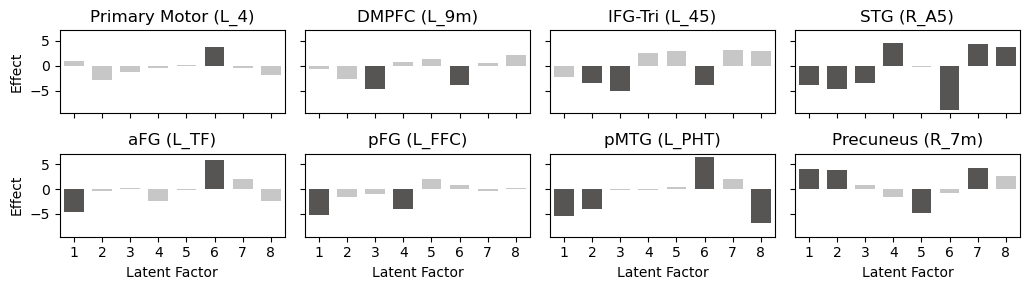

In [170]:
palette_barplot = ["#57535385",'#c7c7c7']

import matplotlib.pyplot as plt
import seaborn as sns
fig,axes = plt.subplots(nrows=2,ncols=4,figsize=(8*1.3,3),sharex=True,sharey=True)


List_parcels = ['L_4','L_9m','L_45','R_A5',
                'L_TF','L_FFC','L_PHT','R_7m',] #10v
List_labels = ['Primary Motor','DMPFC','IFG-Tri','STG',
               'aFG','pFG','pMTG','Precuneus']
for parcel, ax,label in zip(List_parcels,axes.flatten(),List_labels):
    df_plot = df_results.loc[df_results['label']==f'{parcel}_ROI'].copy()
    sns.barplot(df_plot,x='iFA',y='ROI_value',ax=ax,
                width=0.7,hue='significant_FDR',palette = palette_barplot,hue_order = [1,0]).set_title(f"{label} ({parcel})")
    ax.get_legend().set_visible(False)
    ax.set(xlabel='Latent Factor',ylabel='Effect')
    

plt.tight_layout()
file = f'Fig_{pipeline}_{render}_color{colormap}_p005FDR_barplot.jpg'
fig.savefig(os.path.join(Dir_output,file),dpi=600,bbox_inches = 'tight')

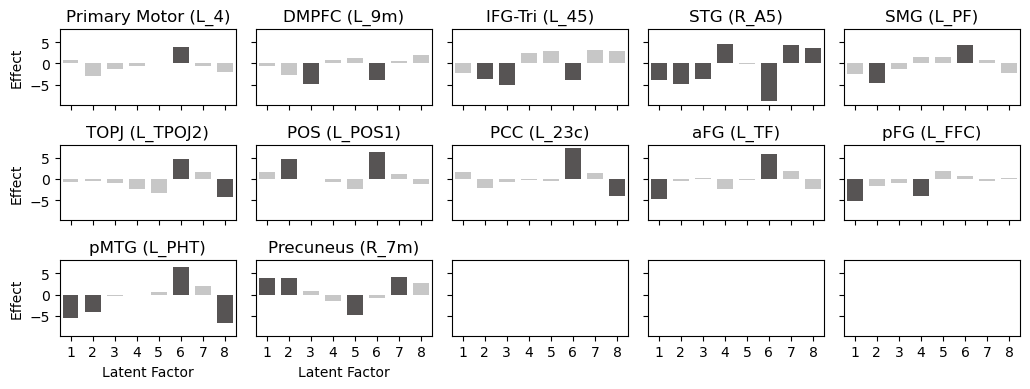

In [185]:
palette_barplot = ["#57535385",'#c7c7c7']

import matplotlib.pyplot as plt
import seaborn as sns
fig,axes = plt.subplots(nrows=3,ncols=5,figsize=(8*1.3,4),sharex=True,sharey=True)


List_parcels = ['L_4','L_9m','L_45','R_A5',
                'L_PF','L_TPOJ2','L_POS1','L_23c',
                'L_TF','L_FFC','L_PHT','R_7m',] #10v
List_labels = ['Primary Motor','DMPFC','IFG-Tri','STG',
               'SMG','TOPJ','POS','PCC',
               'aFG','pFG','pMTG','Precuneus']
for parcel, ax,label in zip(List_parcels,axes.flatten(),List_labels):
    df_plot = df_results.loc[df_results['label']==f'{parcel}_ROI'].copy()
    sns.barplot(df_plot,x='iFA',y='ROI_value',ax=ax,
                width=0.7,hue='significant_FDR',palette = palette_barplot,hue_order = [1,0]).set_title(f"{label} ({parcel})")
    ax.get_legend().set_visible(False)
    ax.set(xlabel='Latent Factor',ylabel='Effect')
    

plt.tight_layout()
# file = f'Fig_{pipeline}_{render}_color{colormap}_p005FDR_barplot.jpg'
# fig.savefig(os.path.join(Dir_output,file),dpi=600,bbox_inches = 'tight')

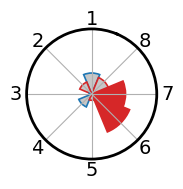

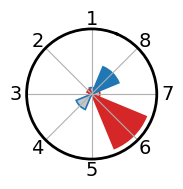

In [305]:

import numpy as np
import matplotlib.pyplot as plt



List_parcels = ['L_4','L_9m','L_45','R_A5',
                'L_PF','L_TPOJ2','L_POS1','L_23c',
                'L_TF','L_FFC','L_PHT','R_7m','L_10v','R_STSdp','R_STSvp','R_STV','L_SFL','L_55b','L_PHA1','L_PFm',
                'L_IFSa',]
List_parcels = ['L_TE2p','R_TE2p','L_TE1p','L_POS2','L_7m','L_PH']
List_parcels = ['L_TE1p','L_STSdp','L_STSvp','L_44','L_IFSp','L_3a','R_23c','L_24dd','R_24dd','L_24dv','R_8BM','L_PHA2','R_13l','R_45','R_IFSa']
List_parcels = ['R_23c','R_44','R_IFSp','R_55b','R_TE1m','R_PHA2']
List_parcels = ['R_TF','L_IFJp','L_PSL','L_PoI2','R_RSC','R_POS1','R_v23ab','R_POS2']
List_parcels = ['L_IFJa','L_PHA3']
for parcel in List_parcels:
    df = df_results.loc[df_results['label'] == f'{parcel}_ROI'].copy().reset_index()
    df.loc[(df['ROI_value']<0)&(df['significant_FDR']==1),'color'] = 'neg_sig'
    df.loc[(df['ROI_value']<0)&(df['significant_FDR']==0),'color'] = 'neg_nonsig'
    df.loc[(df['ROI_value']>=0)&(df['significant_FDR']==1),'color'] = 'pos_sig'
    df.loc[(df['ROI_value']>=0)&(df['significant_FDR']==0),'color'] = 'pos_nonsig'

    df['value'] = df['ROI_value'].abs()


    N = len(df)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

    width = 2 * np.pi / N

    # Color mapping
    color_map = {
        'pos_sig': '#d62728',
        'pos_nonsig': "#c7c7c7",
        'neg_sig': '#1f77b4',
        'neg_nonsig': '#c7c7c7',
    }
    color_map_edge = {
        'pos_sig': '#d62728',
        'pos_nonsig': "#d62728",
        'neg_sig': '#1f77b4',
        'neg_nonsig': '#1f77b4',
    }

    colors = df['color'].map(color_map)
    colors_edge = df['color'].map(color_map_edge)

    align='edge'

    # Create plot
    fig, ax = plt.subplots(figsize=(2, 2), subplot_kw=dict(polar=True))

    # Polar bars
    ax.bar(
        angles,
        df['value'],
        width=width,
        color=colors,
        edgecolor=colors_edge,
        linewidth=1.2,    
        # alpha=0.8,
        align='edge'
    )

    # 🔑 rotation so 1 & 8 are centered at the top
    ax.set_theta_offset(np.pi / 2 - width / 2)
    # ax.set_theta_direction(-1)

    # Labels
    ax.set_xticks(angles + width / 2)
    ax.set_xticklabels(df['iFA'])

    ax.set_ylim(0, df_results['ROI_value'].abs().max() * 1.1)
    ax.set_yticklabels([])

    # Legend
    # legend_handles = [
    #     plt.Line2D([0], [0], color='red', lw=6, label='sig = 1'),
    #     plt.Line2D([0], [0], color='gray', lw=6, label='sig = 0'),
    #     plt.Line2D([0], [0], color='blue', lw=6, label='sig = -1'),
    # ]
    # ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.3, 1.1))

    # ax.grid(False)
    ax.yaxis.grid(False)
    ax.spines['polar'].set_linewidth(2)
    # ax.spines['polar'].set_visible(False)
    ax.tick_params(axis='x', pad=-3,labelsize=14)
    # ax.set_title(parcel, fontsize=14, pad=25)
    plt.tight_layout()
    # plt.show()

    file = f"Fig_{pipeline}_{render}_color{colormap}_p005FDR_radarplot_FAn{df['significant_FDR'].sum()}_{parcel}.png"
    fig.savefig(os.path.join(Dir_output,file),dpi=600,transparent=True,bbox_inches='tight')
    # plt.close()

In [300]:
parcel

'L_Pol2'